# Notebook for PlatoSim paper (2023)

This notebook is used to generate all input plots shown in the PlatoSim3 paper (Jannsen et al., 2023).

Sources:

https://lscsoft.docs.ligo.org/ligo.skymap/plot/allsky.html#

https://matplotlib.org/stable/gallery/lines_bars_and_markers/scatter_with_legend.html

https://stackoverflow.com/questions/43812911/adding-second-legend-to-scatter-plot

In [1]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib notebook

In [2]:
import os
import h5py
import scipy
import wotan
import numpy as np
import pandas as pd
from tqdm import tqdm 

from matplotlib import pyplot as plt
import matplotlib.colors  as colors
import matplotlib.patches as patches

from astropy.io import fits
from astropy import units as u
from astropy.coordinates import SkyCoord

from scipy.signal import periodogram
from scipy.ndimage import median_filter
from scipy.interpolate import interp2d

import transitleastsquares as tls

# PlatoSim
import platosim.referenceFrames as rf
import platosim.plot            as pt
import platosim.utilities       as ut
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
from platosim.lightcurve   import LightCurve
from platosim.validation import switchOffAllEffects
from platosim.matplotlibrc import setup_paper
setup_paper()

# Constants
day = 86400

---
## PLATO LOPS1
---

<IPython.core.display.Javascript object>


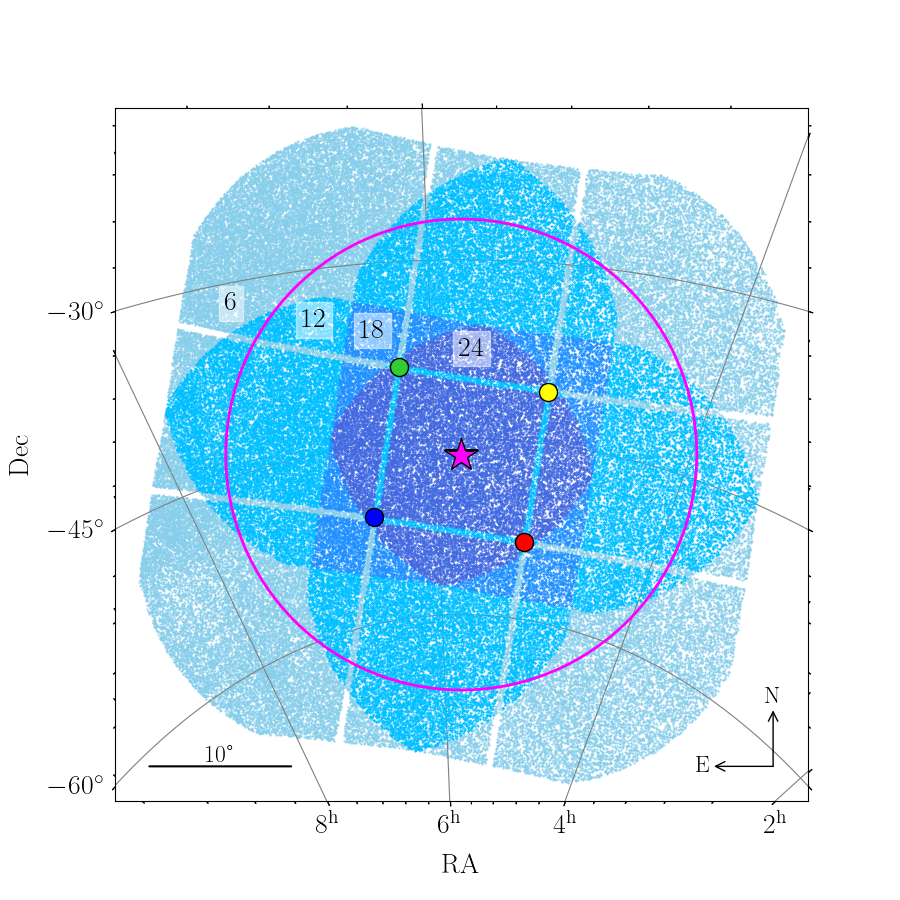

In [7]:
# Plot overall figure
fig, ax = pt.plotPlatoFOV('SPF', fs=20, system='icrs', showGroups=True)

# Plot N-CAM visibility
box1 = fig.text(0.250, 0.655, '6',  fontsize=20)
box2 = fig.text(0.335, 0.637, '12', fontsize=20)
box3 = fig.text(0.400, 0.625, '18', fontsize=20)
box4 = fig.text(0.510, 0.605, '24', fontsize=20)

# Plot white boxes below
box1.set_bbox(dict(facecolor='w', alpha=0.5, edgecolor='w'))
box2.set_bbox(dict(facecolor='w', alpha=0.5, edgecolor='w'))
box3.set_bbox(dict(facecolor='w', alpha=0.5, edgecolor='w'))
box4.set_bbox(dict(facecolor='w', alpha=0.5, edgecolor='w'))

import matplotlib.ticker as mticker
ticks_major = np.array([8, 6, 4, 2]) * 15
ax.xaxis.set_major_locator(mticker.FixedLocator(ticks_major))
ax.set_xticklabels(ticks_major)

plt.show()

# Save figure
fig.savefig('PlatoFOV.png', bbox_inches='tight', dpi=200)

In [ ]:
# pt.plot_test("SPF", fs=20, system='icrs', showGroups=True);

---
## Spectral Response curve
---

In [8]:
grid_no = 1000
path = os.getenv("PLATO_PROJECT_HOME") + "/python/platosim/varsim/data"

# Import PLATO passband
wvl_plato = np.loadtxt(f"{path}/response_plato.txt")[:,0]  # [nm]                                                                                                                
tra_plato = np.loadtxt(f"{path}/response_plato.txt")[:,1]  # Absolute
# Normalize passband
tra_plato /= tra_plato.max()
wvl_int_plato  = np.linspace(wvl_plato[0], wvl_plato[-1], grid_no)                                                                                                                                         
passband_plato = scipy.interpolate.make_interp_spline(wvl_plato, tra_plato, k=3)                                                                                                                                             
tran_int_plato = passband_plato(wvl_int_plato)

# Import TESS passband
wvl_tess = np.loadtxt(f"{path}/response_tess.txt")[:,0]                                                                                                                
tra_tess = np.loadtxt(f"{path}/response_tess.txt")[:,1]                                                                                                              
wvl_int_tess  = np.linspace(wvl_tess[0], wvl_tess[-1], grid_no)                                                                                                                                         
passband_tess = scipy.interpolate.make_interp_spline(wvl_tess, tra_tess, k=3)                                                                                                                                             
tran_int_tess = passband_tess(wvl_int_tess)                                                                                                                                                             
 
# Import Kepler passband                                                                                                                                                                                                                                                                                                                                                                                          
wvl_kepler  = np.loadtxt(f"{path}/response_kepler.txt")[:,0]                                                                                                                  
tran_kepler = np.loadtxt(f"{path}/response_kepler.txt")[:,1]                                                                                                                      
wvl_int_kepler  = np.linspace(wvl_kepler[0], wvl_kepler[-1], grid_no)                                                                                                                                   
passband_kepler = scipy.interpolate.make_interp_spline(wvl_kepler, tran_kepler, k=3)                                                                                                                                      
tran_int_kepler = passband_kepler(wvl_int_kepler) 

<IPython.core.display.Javascript object>


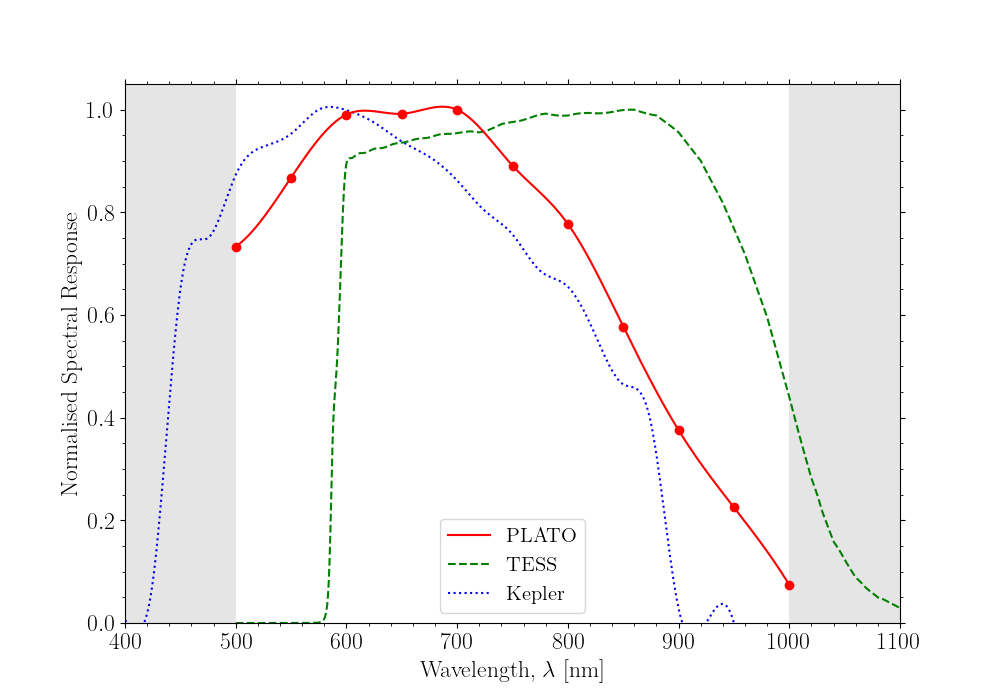

In [9]:
# Create the plot                                                                                                                                                                                                                                                                                                                                                                                              
fig, ax = plt.subplots(1, 1, figsize=(10, 7))                                                                                                                                                   
                                                                                                                                                                                                            
# Response functions:
ax.plot(wvl_plato,  tra_plato, 'ro') 
ax.plot(wvl_int_plato,  tran_int_plato,  'r-',  label='PLATO',  zorder=3) 
ax.plot(wvl_int_tess,   tran_int_tess,   'g--', label='TESS',   zorder=2)                                                                                                                                        
ax.plot(wvl_int_kepler, tran_int_kepler, 'b:',  label='Kepler', zorder=1)  
ax.axvspan(400, 500, color='k', alpha=0.1, lw=0)
ax.axvspan(1000, 1100, color='k', alpha=0.1, lw=0)
ax.set_xlabel(r'Wavelength, $\lambda$ [nm]')                                                                                                                                                          
ax.set_ylabel(r'Normalised Spectral Response')                                                                                                                                             
ax.set_xlim(400, 1100)
ax.set_ylim(0, 1.05)
ax.legend()
plt.show()

# Save figure
fig.savefig('passbands.pdf', bbox_inches='tight', dpi=200)

In [10]:
# grid_no = 1000
# path = os.getenv("PLATO_PROJECT_HOME") + "/python/platosim/varsim/data"

# # Import PLATO passband
# data = np.loadtxt(f"{path}/response_plato_v2.txt")                                                                                                                

# wvl = data[:,0] # [nm] 
# tran_ncam = data[:,1]
# tran_fcam_blue = data[:,3]
# tran_fcam_red  = data[:,4]
# qe  = data[:,5]

# tran_ncam = tran_ncam * qe / np.nanmax(tran_ncam * qe)
# tran_fcam_blue = tran_fcam_blue * qe / np.nanmax(tran_fcam_blue * qe)
# tran_fcam_red  = tran_fcam_red  * qe / np.nanmax(tran_fcam_red  * qe)

In [11]:
# # Create the plot                                                                                                                                                                                                                                                                                                                                                                                              
# fig, ax = plt.subplots(1, 1, figsize=(10, 7))                                                                                                                                                   
                                                                                                                                                                                                            
# # Response functions:
# ax.plot(wvl,  tran_ncam,      'go')
# ax.plot(wvl,  tran_fcam_blue, 'bo')
# ax.plot(wvl,  tran_fcam_red,  'ro')
# ax.plot(wvl_int_plato,  tran_int_plato,  'g-',  label='PLATO',  zorder=3) 
# ax.plot(wvl_int_tess,   tran_int_tess,   'm--', label='TESS',   zorder=2)                                                                                                                                        
# ax.plot(wvl_int_kepler, tran_int_kepler, 'c:',  label='Kepler', zorder=1)

# ax.axvspan(400, 500, color='k', alpha=0.1, lw=0)
# ax.axvspan(1000, 1100, color='k', alpha=0.1, lw=0)
# ax.set_xlabel(r'Wavelength, $\lambda$ [nm]')                                                                                                                                                          
# ax.set_ylabel(r'Normalised Spectral Response')                                                                                                                                             
# ax.set_xlim(400, 1100)
# ax.set_ylim(0, 1.05)
# ax.legend()
# plt.show()

---
## Sky background
---

<IPython.core.display.Javascript object>


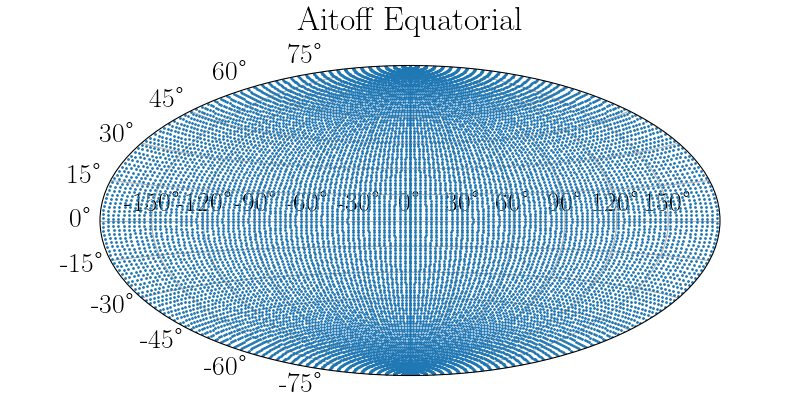

In [3]:
# First make a grid in Equatorial coordinates
N = 120
x = np.linspace(0, 360, N)
y = np.linspace(-90, 90, N)
x, y = np.meshgrid(x, y)
RA  = x.flatten() * u.degree
Dec = y.flatten() * u.degree

c = SkyCoord(ra=RA, dec=Dec, frame='icrs')
ra_rad = c.ra.wrap_at(180 * u.deg).radian
dec_rad = c.dec.radian
RA, Dec = RA.value, Dec.value

plt.figure(figsize=(8,4.2))
plt.subplot(111, projection="aitoff")
plt.title("Aitoff Equatorial", pad=25)
plt.grid(True)
plt.plot(ra_rad, dec_rad, 'o', markersize=1)
plt.subplots_adjust(top=0.95,bottom=0.0)
plt.show()

<IPython.core.display.Javascript object>


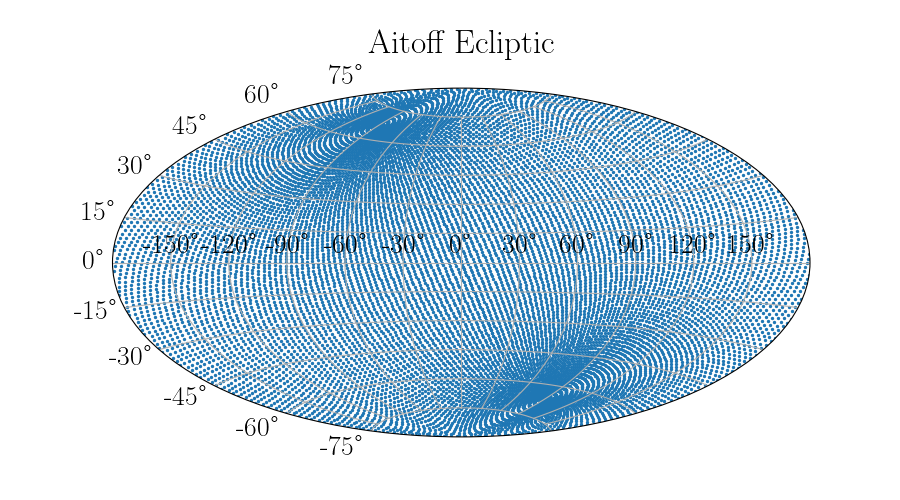

In [4]:
# Compared to the Galactic coordinate system
eli = c.geocentricmeanecliptic
l = -eli.lon.wrap_at("180d").radian
b = eli.lat.radian

plt.figure(figsize=(9,5))
plt.subplot(111, projection="aitoff")
plt.title("Aitoff Ecliptic", pad=25)
plt.grid(True)
plt.scatter(l, b, s=2)
plt.subplots_adjust(top=0.95,bottom=0.0)
plt.show()

<IPython.core.display.Javascript object>


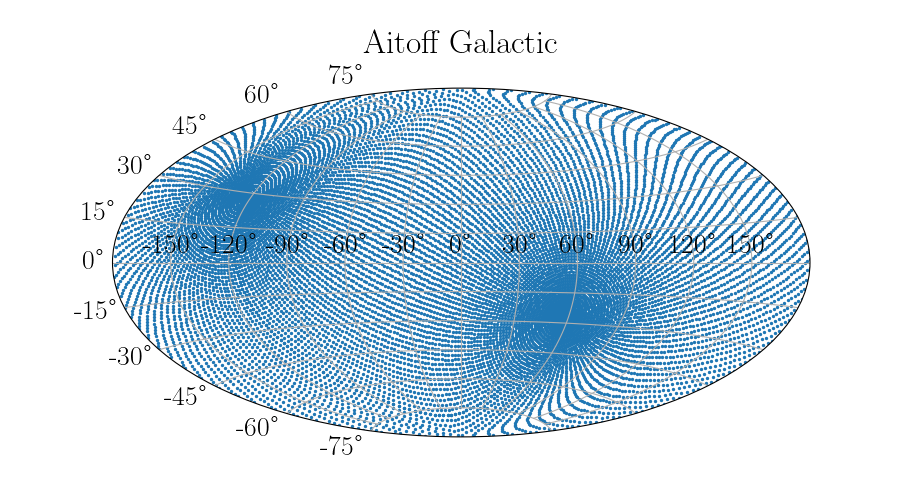

In [5]:
# Compared to the Galactic coordinate system
gal = c.galactic
l = -gal.l.wrap_at("180d").radian
b = gal.b.radian

plt.figure(figsize=(9,5))
plt.subplot(111, projection="aitoff")
plt.title("Aitoff Galactic", pad=25)
plt.grid(True)
plt.scatter(l, b, s=2)
plt.subplots_adjust(top=0.95,bottom=0.0)
plt.show()

In [7]:
# Compute the sky background for each grid point (as pointing) using PlatoSim
N = len(RA)
sky = np.zeros(N)

for i, ra, dec in zip(tqdm(range(N), bar_format=ut.tqdmBar()), RA, Dec):
    
    sim = Simulation("output_skybackground", outputDir=os.getcwd())
    switchOffAllEffects(sim)
    
    # One full-frame exposure
    sim["ObservingParameters/NumExposures"] = 1
    sim["ObservingParameters/RApointing"]   = ra
    sim["ObservingParameters/DecPointing"]  = dec
    sim["Sky/SkyBackground"]   = -1
    sim["SubField/NumRows"]    = 1
    sim["SubField/NumColumns"] = 1
    
    # Define catalogue
    if i == 0:
        row = np.array([0])
        col = np.array([0])
        mag = np.array([30])
        ID  = [0]
        starcatFile = os.getcwd() + "/starcat.txt"
    sim.createStarCatalogFileFromPixelCoordinates(row, col, mag, ID, starcatFile)
    
    # Set subfield to same location as platform pointing
    sim.setSubfieldAroundCoordinates(ra, dec, 1, 1, normal=True)
    
    # Simulate each sky background
    simfile = sim.run(removeOutputFile = True)
    sky[i] = simfile.getImage(0)

  0%|                                                  | 0/14400 [00:00<?, ?it/s]                                                                                                                           


2023-03-08 16:34:57 ERROR   ConfigurationParameters: The sub-field "Orientation" of field "Platform" is not available in the configuration file (/lhome/nicholas/software/PlatoSim3/docs/technicalnotes/PlatoSim3Paper/output_skybackground.yaml).
terminate called after throwing an instance of 'IllegalArgumentException'
  what():  ConfigurationParameters: The sub-field "Orientation" of field "Platform" is not available in the configuration file (/lhome/nicholas/software/PlatoSim3/docs/technicalnotes/PlatoSim3Paper/output_skybackground.yaml).



Exception: Simulation.run(): PlatoSim returned with exit code -6.

In [29]:
data = np.loadtxt(f"{os.getcwd()}/sky0.txt")
RA, Dec, sky = data[:,0], data[:,1], data[:,2]
# np.savetxt(os.getcwd() + "/sky0.txt", np.transpose([RA.value, Dec.value, sky]))
Dec *= -1
for i in range(len(RA)):
    if Dec[i] >= 0:
        RA[i] -= 5.8
    else:
        RA[i] += 5.8

<IPython.core.display.Javascript object>


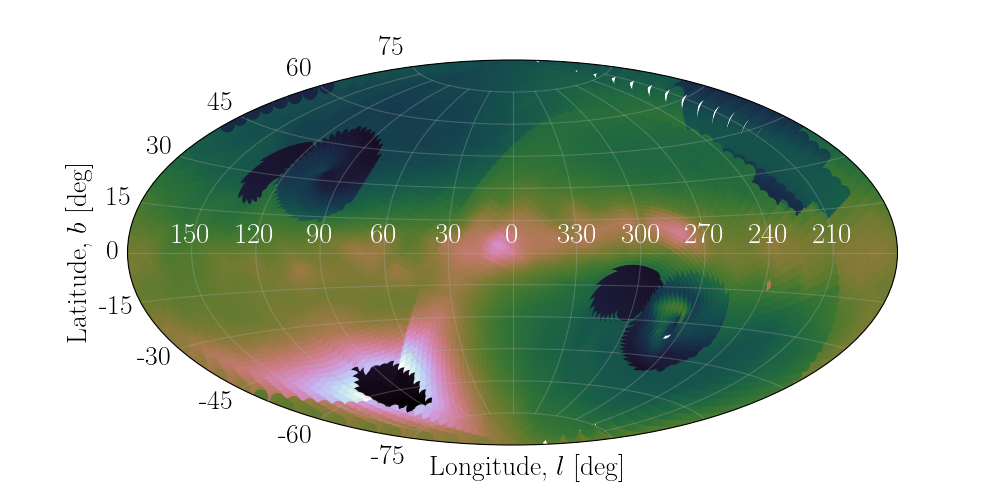

In [30]:
# Add the sky projection ontop as transparent layer
fig, ax = plt.subplots(figsize=(10,5))
axes = fig.add_subplot(111, projection='aitoff', facecolor='none')

# Bases
lon = np.deg2rad(np.linspace(-102, 258, 100)) # -102, 258, 100)
lat = np.zeros_like(lon)
ecli = SkyCoord(frame="geocentricmeanecliptic", lon=lon, lat=lat, unit=u.radian)
equa = SkyCoord(RA, Dec, frame='icrs', unit=u.deg)

# Equatorial
# x = -equa.ra.wrap_at('180d').radian
# y = equa.dec.radian
# equa_line = ecli.transform_to("icrs")
# x_line = -equa_line.ra.wrap_at('180d').radian
# y_line = equa_line.dec.radian
# plt.plot(x_line, y_line, "--", c="royalblue", lw=2, zorder=1)
# axes.set_xlabel(r'RA, $\alpha$ [deg]')
# axes.set_ylabel(r'Dec, $\delta$ [deg]')

# Ecliptic
# grid = equa.geocentricmeanecliptic #barycentricmeanecliptic
# x = -grid.lon.wrap_at('180d').radian
# y = grid.lat.radian
# axes.set_xlabel(r'Longitude, $\lambda$ [$^{\circ}$]')
# axes.set_ylabel(r'Latitude, $\beta$ [$^{\circ}$]')

# Galactic
grid = equa.galactic
x = -grid.l.wrap_at('180d').radian
y = grid.b.radian
line = ecli.galactic
x_line = -line.l.wrap_at('180d').radian
y_line = line.b.radian
plt.plot(x_line, y_line, "--", c="royalblue", lw=2, zorder=-1)
axes.set_xlabel(r'Longitude, $l$ [deg]')
axes.set_ylabel(r'Latitude, $b$ [deg]')

# Plot Aitoff projection in Galactic coordinates
fs, ms = 20, 100

# Plot the targets on the sky (autumn_r, rainbow)
im = plt.scatter(x, y, c=sky, s=ms, cmap="cubehelix", norm=colors.LogNorm(), zorder=-1)

# Vertical or horizontal colorbar showing magnitudes
cbarax = fig.add_axes([0.25, -0.05, 0.52, 0.03])
sky_min = sorted(sky)[1]
sky_max = np.max(sky)
cbar = plt.colorbar(im, orientation='horizontal', cax=cbarax, extend='both')
cbar.set_label(r'Sky background flux, $F_{\rm sky}$ [$\gamma \ s^{-1} \ \rm pixel^{-1}$]', fontsize=fs)
cbar.ax.tick_params(labelsize=fs)

# Change the tick labels so that they are 0->360, rather than -180->+180
tickLabels = np.array([150, 120, 90, 60, 30, 0, 330, 300, 270, 240, 210])
# tickLabels = np.remainder(tickLabels+360, 360)
axes.set_xticklabels(tickLabels)

# Change y ticks and remove last to make space for title
tickLabels = np.array([-75, -60, -45, -30, -15, 0, 15, 30, 45, 60, 75])
axes.set_yticklabels(tickLabels)

# Plot ticks on top of data 
axes.tick_params(axis='both', which='major', labelsize=15, zorder=1)
axes.tick_params(axis='x', colors='w')

# Increase x and y tick labels
axes.xaxis.set_tick_params(labelsize=fs+1)
axes.yaxis.set_tick_params(labelsize=fs)

# Add axes labels
axes.xaxis.set_label_coords(0.52, -0.025)

# Set grid and remore outer ticks (if set by default)
axes.grid(True, alpha=0.3)
ax.axis('off')
plt.draw()
# plt.tight_layout()

# Save figure
fig.savefig('skybackground.png', bbox_inches='tight', dpi=200)

---
## Jitter comparison: Prime vs. Red noise
---

In [ ]:
# Load Prime
path = "/lhome/nicholas/Nextcloud/Platoman/Models/Jitter/Prime2020jan"
df = pd.read_csv(f'{path}/01_PLATO_PDR_FPM_02_longrun_APE.csv', delimiter=';', 
                 names=['t', 'x', 'y', 'z'], skiprows=[0,1])

# Let time series start at zero seconds
df['t'] -= df['t'].iloc[0]

# Convert angles from rad -> arcsec
for n in ['x', 'y', 'z']:
    df[n] = df[n] * 206265. 
    
df.head()

In [ ]:
# Load simulated PlatoSim red noise jitter
f = h5py.File(f"{os.getcwd()}/redNoiseJitter8Hz.hdf5", "r")
x = f['ACS/Yaw'][:]

In [ ]:
# Compute PSD for Prime data
f_prime, psd_prime = periodogram(df["x"], 8, scaling='density')
f_prime   *= 1e6  # [muHz]
psd_prime *= 1e6  # [ppm^2/muHz]

# Compute PSF for PlatoSim red noise
f_red, psd_red = periodogram(x, 8, scaling='density')
f_red   *= 1e6  # [muHz]
psd_red *= 1e6  # [ppm^2/muHz]

# Median filters of 1 min
n = int(60 / 0.125)
psd_prime_med = scipy.ndimage.median_filter(psd_prime, n)
psd_red_med   = scipy.ndimage.median_filter(psd_red,   n)

In [ ]:
# Old figure with OHB jitter included
fig, ax = plt.subplots(2, 1, figsize=(8,7))

ax[0].plot(f_red, psd_red,         "-", c='tomato', label="Red noise model", lw=0.8)
ax[0].plot(f_red, psd_red_med,     "k-", label="1 min median")
ax[1].plot(f_prime, psd_prime,     "-", c='royalblue', label="OHB/Thales model", lw=0.8)
ax[1].plot(f_prime, psd_prime_med, "k-", label="1 min median")

for i in range(2):
    ax[i].set_xlim(1e2, f_prime.max())
    ax[i].set_ylim(1e-7, 1e6)
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')

fig.text(0.50, 0.04, r"Frequency, $\nu$ [$\mu$Hz]",   ha="center")
fig.text(0.02, 0.50, r"PSD [ppm$^2$ $\mu$Hz$^{-1}$]", va="center", rotation="vertical")
ax[0].legend()
ax[1].legend()
plt.show()

# Save figure
fig.savefig('jitter.png', bbox_inches='tight', dpi=200)

In [ ]:
# # Creaet plot
# fig, ax = plt.subplots(1, 1, figsize=(10,4))

# ax.plot(f_red, psd_red,     "k-", label="Red noise model", lw=0.8)
# ax.plot(f_red, psd_red_med, "r-", label="1 min median")
# ax.set_xlim(1e1, np.max(f_red))
# ax.set_ylim(1e-6, 1e6)
# ax.set_xscale('log')
# ax.set_yscale('log')
# ax.set_xlabel(r"Frequency, $\nu$ [$\mu$Hz]")
# ax.set_ylabel(r"PSD [ppm$^2$ $\mu$Hz$^{-1}$]")
# ax.legend()
# plt.show()

# # Save figure
# fig.savefig('jitter.png', bbox_inches='tight', dpi=200)

---
## CCD subfields
---

In [ ]:
# Initialise PlatoSim (we reuse the inputfile.yaml)
outputFileName = "output_Image"
sim = Simulation(outputFileName, outputDir=outputDir)

# Obs parameters
sim["ObservingParameters/NumExposures"]    = 1

# Sky parameters
sim["Sky/SkyBackground"]         = -1  # Auto background
sim["Sky/Cosmics/CosmicHitRate"] = 10

# Subfield 1000, 1100
rows, cols = 1000, 900
sim["SubField/NumColumns"]      = 400
sim["SubField/NumRows"]         = 400
sim["SubField/ZeroPointColumn"] = cols
sim["SubField/ZeroPointRow"]    = rows

# Run simulation
simfile0 = sim.run(removeOutputFile=True)

In [ ]:
# Show image
f0 = SimFile(outputFileName + ".hdf5")
fig, ax = f0.showImage(0, clipPercentile=1.1, figsize=(10,10), colorMap="cubehelix",
                      showStarPositions=False, showStarIDs=True, useTitle=False,
                      fontSize=35)
# Save figure
fig.savefig('subfield400x400pix.png', bbox_inches='tight', dpi=200)

In [ ]:
# Find target from ,catalogue of Image
cat = simfile0.getStarCoordinates(0)
starID = 10
rowStar = int(cat[1][starID])
colStar = int(cat[2][starID])
fluxStar = int(cat[-1][starID])
rowStar, colStar

In [ ]:
# Initialise PlatoSim
outputFile = "output_imagette"
sim = Simulation(outputFile, outputDir=outputDir)

# Observation
sim["ObservingParameters/NumExposures"] = 1

# Sky
sim["Sky/SkyBackground"]         = -1  # Auto background
sim["Sky/Cosmics/CosmicHitRate"] = 10

# Subfield
sim["SubField/NumColumns"]      = 6
sim["SubField/NumRows"]         = 6
sim["SubField/ZeroPointColumn"] = cols + colStar - 3
sim["SubField/ZeroPointRow"]    = rows + rowStar - 3

# Control HDF5
sim["ControlHDF5Content/WriteStarPositions"]     = True
sim["ControlHDF5Content/WriteDiffusedPSF"]       = True
sim["ControlHDF5Content/WriteHighResolutionPSF"] = True

# Run simulation
simfile = sim.run(removeOutputFile=True)

In [ ]:
# Show image
f = SimFile(outputFile + ".hdf5")
fig, ax = f.showImage(0, figsize=(10,10), 
                      colorBar=True, imgScale="auto", colorMap="cubehelix",
                      showStarPositions="PIC", showStarIDs=False, useTitle=False,
                      showGrid=True, fontSize=30, tarMarkerSize=500) 

# # Save figure
fig.savefig('subfield6x6pix.png', bbox_inches='tight', dpi=200)

# Print the star magnitude used
f.getStarCatalog()[3]

---
## CTI for EOL
---

In [ ]:
# Initialise PlatoSim
sim = Simulation("output_CTI", outputDir=os.getcwd())

# Observation
exp = int(6.5 * 365 * 24 * 60 * 60 / 25.)
sim["ObservingParameters/BeginExposureNr"] = exp
sim["ObservingParameters/NumExposures"]    = 1

# Sky
sim["Sky/SkyBackground"]         = -1  # Auto background
sim["Sky/Cosmics/CosmicHitRate"] = 10

# Subfield
sim["SubField/NumColumns"]      = 200
sim["SubField/NumRows"]         = 200
sim["SubField/ZeroPointColumn"] = 2900
sim["SubField/ZeroPointRow"]    = 3100

# Save to HDF5
sim["ControlHDF5Content/WriteTransmissionEfficiency"] = True

# Run simulation
simFile = sim.run(removeOutputFile=True)

In [ ]:
# Load file
f = SimFile("output_CTI.hdf5")

# Show image
fig, ax = f.showImage(exp, colorMap="cubehelix", clipPercentile=0.8, figsize=(10,10),
                      showStarPositions=False, showStarIDs=True, useTitle=False,
                      colorBar=True, imgScale="auto", fontSize=20, showGrid=False, origin="upper")
ax.set_xlabel(r'Subfield pixel column, $i$')
ax.set_ylabel(r'Subfield pixel row, $j$')

# Save figure
fig.savefig('cti.png', bbox_inches='tight', dpi=200)

---
## Throughput map
---

In [ ]:
exp = 1
outputFile = "output_TM"
sim = Simulation(outputFile, outputDir=os.getcwd())

In [ ]:
# # Initialise PlatoSim

# # Observation
# sim["ObservingParameters/BeginExposureNr"] = exp
# sim["ObservingParameters/NumExposures"]    = 1

# # Sky
# sim["Sky/SkyBackground"]         = -1  # Auto background
# sim["Sky/Cosmics/CosmicHitRate"] = 0

# # Subfield
# sim["SubField/NumColumns"]      = 4510
# sim["SubField/NumRows"]         = 4510
# sim["SubField/ZeroPointColumn"] = 0
# sim["SubField/ZeroPointRow"]    = 0

# # Save to HDF5
# sim["ControlHDF5Content/WriteTransmissionEfficiency"] = True

# # Run simulation
# simFile = sim.run(removeOutputFile=True)

In [ ]:
# Load file
f = SimFile(outputFile + ".hdf5")
tm = f.getThroughputMap(exp)
tm *= 100 * np.ones_like(tm)

# Get constants
pixelSize   = f.getInputParameter("CCD", "PixelSize")
focalLength = f.getInputParameter("Camera/FocalLength", "ConstantValue") * 1e3
ccdZeroPointX = sim['CCDPositions/OriginOffsetX'][0]  # [mm]
ccdZeroPointY = sim['CCDPositions/OriginOffsetX'][0]  # [mm]
distortionCoefficients = sim['Camera/FieldDistortion/ConstantCoefficients']

# Calculate diagonal offset betwee FP origo and CCD origo [deg]
alpha_offset = np.rad2deg(rf.gnomonicRadialDistanceFromOpticalAxis(ccdZeroPointX, ccdZeroPointY, focalLength))

# Radial flux cut-off from stray light mask (undistorted and distorted)
alpha_max_und = np.deg2rad(18.9)
alpha_max_exp = np.deg2rad(20.0)
xFP_max_und, yFP_max_und = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(alpha_max_und, focalLength, inPlaneRotation=45.)
xFP_max_dis, yFP_max_dis = rf.undistortedToDistortedFocalPlaneCoordinates(xFP_max_und, yFP_max_und, distortionCoefficients, focalLength)
xFP_max_exp, yFP_max_exp = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(alpha_max_exp, focalLength, inPlaneRotation=45.)
xCCD_max_und, yCCD_max_und = rf.focalPlaneToPixelCoordinates(xFP_max_und, yFP_max_und, pixelSize, 
                                                             ccdZeroPointX=ccdZeroPointX, ccdZeroPointY=ccdZeroPointY, CCDangle=0)
xCCD_max_dis, yCCD_max_dis = rf.focalPlaneToPixelCoordinates(xFP_max_dis, yFP_max_dis, pixelSize, 
                                                             ccdZeroPointX=ccdZeroPointX, ccdZeroPointY=ccdZeroPointY, CCDangle=0)
xCCD_max_exp, yCCD_max_exp = rf.focalPlaneToPixelCoordinates(xFP_max_exp, yFP_max_exp, pixelSize, 
                                                             ccdZeroPointX=ccdZeroPointX, ccdZeroPointY=ccdZeroPointY, CCDangle=0)
r_max_und = np.sqrt(xCCD_max_und**2 + yCCD_max_und**2)
r_max_dis = np.sqrt(xCCD_max_dis**2 + yCCD_max_dis**2)
r_max_exp = np.sqrt(xCCD_max_exp**2 + yCCD_max_exp**2)

# Find alpha_max in pixels
alpha = np.arange(0,22,2)
xFP, yFP = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(np.deg2rad(alpha), focalLength, 
                                                              inPlaneRotation=np.deg2rad(45))
xCCD, yCCD = rf.focalPlaneToPixelCoordinates(xFP, yFP, pixelSize, 
                                             ccdZeroPointX=ccdZeroPointX, ccdZeroPointY=ccdZeroPointY, CCDangle=0)

# Revert the inclusion of the QE
tm0 = tm / (sim["CCD/QuantumEfficiency/MeanQuantumEfficiency"] * sim["CCD/QuantumEfficiency/MeanAngleDependency"])
tm0 = tm

In [ ]:
# a = np.rad2deg(rf.gnomonicRadialDistanceFromOpticalAxis(2.857, 2.857, focalLength))
r_max_dis

In [ ]:
# Create plot
fig, ax = plt.subplots(1,1, figsize=(10,10))

# Set zero throughput to different color
tm1 = np.ma.masked_where(tm0 == 0, tm0)
cmap = plt.cm.cubehelix
cmap.set_bad(color='#303030')

im = ax.imshow(tm1, interpolation='nearest', extent=[0, 4510, 0, 4510], cmap=cmap, origin="lower",
               vmin=np.sort(np.unique(tm0))[1], vmax=np.max(tm0))

cbar = fig.colorbar(im, extend='max', shrink=0.84, pad=0.015)                     
cbar.set_label(r"Optical throughput, $(T \cdot Q)$ [\%]", labelpad=3)                                    
cbar.ax.tick_params()

# Plot circle 
ax.add_patch(patches.Circle((0, 0), r_max_und, color='r', ls="--", lw=2.0, fill=False, label="Undist."))
ax.add_patch(patches.Circle((0, 0), r_max_dis, color='r', ls=":",  lw=2.5, fill=False, label="Distort."))
ax.add_patch(patches.Circle((0, 0), r_max_exp, color='r', ls="-",  lw=1.5, fill=False)) #, label="Distort."))

# Plot distance indicator
ax.plot(xCCD, yCCD, "ko:", mec="w", ms=7, label=r"$\alpha$ [$^{\circ}$]")
for i in range(1,len(alpha)): 
    # Change color of labels
#     if i in (1, 2, 3, 4, len(alpha)-2, len(alpha)-1): color = "w"
    if i in (len(alpha)-2, len(alpha)-1): color = "w"
    else: color = "k"
    # Change position of labels
    if i == len(alpha)-1:
        ax.text(xCCD[i]+110, yCCD[i]-60, "{:.0f}".format(alpha[i])+r"$^{\circ}$", color=color, fontsize=21)
    else:
        ax.text(xCCD[i]+70, yCCD[i]-200, "{:.0f}".format(alpha[i])+r"$^{\circ}$", color=color, fontsize=21)
    
ax.set_xlabel(r"Pixel column, $i$")
ax.set_ylabel(r"Pixel row, $j$")
ax.legend(loc='upper right', fontsize=17)
ax.set_xlim(0, 4510)
ax.set_ylim(0, 4510)
# ax.set_xticks(np.arange(0, 250, 50))
# ax.set_yticks(np.arange(0, 250, 50))
plt.show()

# Save figure
fig.savefig('throughput.png', bbox_inches='tight', dpi=200)

In [ ]:
# T_opt = 0.
# T_fil = 1
# T_con = 0.972 * 0.9573
# T_pol = 0.989
# T_vin = 0.920
# QE = 0.6218
# T = T_opt * T_fil * T_con * T_pol * T_vin #* QE
# T

---
## PRNU
---

In [ ]:
# We use the previous simulation to plot the flat-field [%]
prnu = (f.getPRNU() - 1) * 100

# Create plot
fig, ax = plt.subplots(1,1, figsize=(9.5,9.5))

im = ax.imshow(prnu, interpolation='nearest', extent=[0,4510,0,4510], cmap="cubehelix", origin="lower")
cbar = fig.colorbar(im, extend='max', shrink=0.84, pad=0.015)                     
cbar.set_label(r"PRNU [\%]", labelpad=3)                                    
cbar.ax.tick_params()
ax.set_xlabel(r"Pixel column, $i$")
ax.set_ylabel(r"Pixel row, $j$")
# ax.set_xticks(np.arange(0, 250, 50))
# ax.set_yticks(np.arange(0, 250, 50))
plt.show()

# Save figure
fig.savefig('prnu.png', bbox_inches='tight', dpi=200)

---
## Distortion
---

In [ ]:
# Load Zemax PSF
f = h5py.File(os.getenv("PLATO_PROJECT_HOME")+'/inputfiles/PSF_Focus_0mu.hdf5', 'r')
coorUnd = f["Coordinates map"]["Undistorted"]
coorDis = f["Coordinates map"]["Distorted"]

In [ ]:
# Select data
xund   = coorUnd["x"][:]
yund   = coorUnd["y"][:]
xzemax = coorDis["x"][:]
yzemax = coorDis["y"][:]

# Unfortunately the HDF5 file is a mesh.. so we create a grid and select points from this
# x = np.arange(1.3, 85, 4.4)
# y = np.arange(1.3, 85, 4.4)
x = np.arange(1.3, 85, 8.8)
y = np.arange(1.3, 85, 8.8)

xx, yy = np.meshgrid(x,y)
coords = np.array((xx.ravel(), yy.ravel())).T

# Find indices that matches in undistorted grid point best
dex = []
for i in range(len(coords)):
    r = np.sqrt( (xund-coords[i,0])**2 + (yund-coords[i,1])**2 )
    dex.append(np.argmin(r))
xund   = np.array([xund[i] for i in dex])
yund   = np.array([yund[i] for i in dex])
xzemax = np.array([xzemax[i] for i in dex])
yzemax = np.array([yzemax[i] for i in dex])

# Calculate distortion using the Wang model for analytic PSFs
coeff = [0.32419,  0.0232909,  0.407979, 0.00022463, 0.000217599, 0.000381958, 0.000963902]
focalLength = 247.52
xwang, ywang = rf.undistortedToDistortedFocalPlaneCoordinates(xund, yund, coeff, focalLength)

# For plotting FOV limit
fov_max = np.deg2rad(18.8908)
fov_max_mm = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(fov_max, focalLength)[0]

# Remove extra data at deges
rm = [39, 49, 58, 59, 67, 68, 69, 76, 77, 78, 79, 85, 86, 87, 88, 89, 93, 94, 95, 96, 97, 98, 99]
xund = np.delete(xund, rm) 
yund = np.delete(yund, rm) 
xwang = np.delete(xwang, rm) 
ywang = np.delete(ywang, rm) 
xzemax = np.delete(xzemax, rm) 
yzemax = np.delete(yzemax, rm) 

# Find the radial distance from OA for data
alpha = np.rad2deg([rf.gnomonicRadialDistanceFromOpticalAxis(xund[i], yund[i], focalLength) 
                    for i in range(len(xund))])

In [ ]:
# Plot image
fig, ax = plt.subplots(1, 2, figsize=(11,5))

# Plot CCD and FOV footprint
ax[0].add_patch(patches.Rectangle((1.3, 1.3), 82.48-1.3, 82.48-1.3, edgecolor='navy', facecolor='whitesmoke', lw=1.5, label="CCD"))
ax[0].add_patch(patches.Circle((0, 0), fov_max_mm, color='darkorange', ls="--", lw=1.5, fill=False, label="FOV"))
ax[0].scatter(xund,   yund,   s=55,  c="k", edgecolor='w', marker="o", label="Undistorted",      zorder=3)
ax[0].scatter(xwang,  ywang,  s=125, c="r", edgecolor='w', marker="d", label="Wang model",  zorder=2)
for i in range(len(xund)):
    ax[0].plot([xund[i], xwang[i]], [yund[i], ywang[i]], 'k-', zorder=2)

# Plot residuals between Wang / Zemax
ax[1].hlines(0, -0.1, 2.5, color='k', linestyle=':', zorder=0)    
ax[1].vlines(0, -0.1, 2.5, color='k', linestyle=':', zorder=0)    
im = ax[1].scatter(xwang-xzemax, ywang-yzemax, s=50, c=alpha, cmap="jet", edgecolor='k', marker="o", 
                   label="Zemax model", zorder=1)
# Set colorbar
cbar = fig.colorbar(im, extend='max', shrink=1.0, pad=0.02, ticks=[0.5,3,6,9,12,15,18])
cbar.set_label(r"Radial distance from OA, $\alpha$ [$^{\circ}$]", labelpad=0)
# cbar.ax.tick_params(labelsize=fontSize)

# subplot 0
ax[0].set_xlabel(r"Focal plane $x$ [mm]")
ax[0].set_ylabel(r"Focal plane $y$ [mm]")
ax[0].set_aspect('equal', 'box')
ax[0].set_xlim(0, 82.48+1.4)
ax[0].set_ylim(0, 82.48+1.4)
ax[0].legend(fontsize=18, ncols=4, bbox_to_anchor=(-0.02, 1.02))

# subplot 0
ax[1].set_xlabel(r"$x_{\rm wang} - x_{\rm zemax}$ [mm]")
ax[1].set_ylabel(r"$y_{\rm wang} - y_{\rm zemax}$ [mm]")
ax[1].set_aspect('equal', 'box')
ax[1].set_xlim(-0.01, 0.18)
ax[1].set_ylim(-0.01, 0.25);

# Save figure
fig.savefig('distortion.png', bbox_inches='tight', dpi=200)

---
## Vignetting
---

In [ ]:
# # A few constants
# alpha_max = 18.8908
# r = np.linspace(0, alpha_max, 1000)

# # Natural vignetting
# def T_nat(r):
#     return 1 - np.cos(np.deg2rad(r))**2

# # Optical vignetting
# def T_opt(r):
#     sim = Simulation("out")
#     c = sim["CCD/RelativeTransmissivity/Coefficients"]
#     return c[0] * r**2 + c[1] * r**4 + c[2] * r**6

In [ ]:
# # Plot figure
# fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# # Response functions:
# ax.plot(r, T_opt(r)+T_vig(r), 'k-', label='Total')
# ax.plot(r, T_nat(r), '--', c="darkcyan", label='Natural')
# ax.plot(r, T_opt(r), ':',  c="deeppink", label='Optical')
# ax.axvspan(alpha_max, alpha_max+1, color='k', alpha=0.1, lw=0, label="Mechanical")
# # ax.set_yscale('log')
# ax.set_xlabel(r"Radial distance from optical axis, $\alpha$ [deg]")
# ax.set_ylabel("Vignetting")
# ax.set_xlim(0, alpha_max+1)
# ax.set_ylim(0, 19)
# ax.legend();

---
## Spectral transmission
---

In [ ]:
# Import PLATO passband
path = "/lhome/nicholas/Nextcloud/Platoman/Models/TOU"
data = np.loadtxt(f"{path}/optical_transmission_ncam.txt")

In [ ]:
# Create the plot                                                                                                                                                                                       
                                                                                                                                                                                                            
fig, ax = plt.subplots(1, 1, figsize=(10, 7))                                                                                                                                                   
                                                                                                                                                                                                            
# Response functions:
ax.plot(data[:,0],  data[:,1], 'bo-', label='BOL')
ax.plot(data[:,0],  data[:,2], 'ro-', label='EOL') 
# ax.plot(wvl_int_plato,  tran_int_plato,  'r-',  label='PLATO',  zorder=3) 
# ax.plot(wvl_int_tess,   tran_int_tess,   'g--', label='TESS',   zorder=2)                                                                                                                                        
# ax.plot(wvl_int_kepler, tran_int_kepler, 'b:',  label='Kepler', zorder=1)  
ax.axvspan(400, 500, color='k', alpha=0.1, lw=0)
ax.axvspan(1000, 1100, color='k', alpha=0.1, lw=0)
ax.set_xlabel(r'Wavelength, $\lambda$ [nm]')                                                                                                                                                          
ax.set_ylabel(r'Normalised Spectral Response')                                                                                                                                             
ax.set_xlim(450, 1050)
ax.set_ylim(0.5, 1)
ax.legend()
plt.show()

# Save figure
# fig.savefig('passbands.pdf', bbox_inches='tight', dpi=200)

---
## Microscanning
---

In [ ]:
# Constants
cadence  = 25.  # [s]                                                                                                                                                                             
quarter  = 0                                                                                                                                                                                           
day = 86400.                                                                                                                                                                                            

# Load file
filename_bc = os.getenv('PLATO_PROJECT_HOME') + '/inputfiles/microscan_spiral_8Hz_3h_BC.txt'
filename_wc = os.getenv('PLATO_PROJECT_HOME') + '/inputfiles/microscan_spiral_8Hz_3h_WC_01.txt'

data_bc = np.loadtxt(filename_bc)
data_wc = np.loadtxt(filename_wc)
t_bc, x_bc, y_bc, z_bc = data_bc[:,0], data_bc[:,1], data_bc[:,2], data_bc[:,3]
t_wc, x_wc, y_wc, z_wc = data_wc[:,0], data_wc[:,1], data_wc[:,2], data_wc[:,3]

time_points = round(t_bc[-1] / cadence)
timeStart   = round(90. * quarter * day)                                                                                                                                                                   
timeEnd     = round(timeStart + time_points * cadence)                                                                                                                                                    
time        = np.arange(timeStart, timeEnd, cadence)

# Find points at cadence
dex_bc = [ut.findNearestIndex(t_bc, time[i]) for i in range(len(time))]
dex_wc = [ut.findNearestIndex(t_wc, time[i]) for i in range(len(time))]

In [ ]:
# Plot spiral
fig, ax = plt.subplots(1, 2, figsize=(8,4.5))

# Plots
for i in range(2):
    ax[i].axvline(x=-7.5, color='k', linestyle=':')
    ax[i].axvline(x=+7.5, color='k', linestyle=':')
    ax[i].axhline(y=-7.5, color='k', linestyle=':')
    ax[i].axhline(y=+7.5, color='k', linestyle=':')
ax[0].plot(x_bc, y_bc, 'k-')
ax[1].plot(x_wc, y_wc, 'k-')
ax[0].plot(x_bc[dex_bc], y_bc[dex_bc], 'bo', alpha=0.7, ms=4)
ax[1].plot(x_wc[dex_wc], y_wc[dex_wc], 'ro', alpha=0.7, ms=4)

# Labels
ax[0].set_title('Best case', fontsize=22)
ax[1].set_title('Worst case', fontsize=22)                                                                                                                                                                        
fig.text(0.50, -0.01, 'Yaw [arcsec]',   ha="center")
fig.text(-0.01, 0.50, 'Pitch [arcsec]', va="center", rotation=90)

# Settings
for i in range(2):
    ax[i].set_xlim(-10,10)
    ax[i].set_ylim(-10,10)
    ax[i].set_aspect('equal', 'box')
    ax[i].locator_params(axis='x', nbins=5)
    ax[i].locator_params(axis='y', nbins=5)
ax[1].yaxis.set_ticklabels([])
ax[1].xaxis.set_ticklabels(["","-5","0", "5", "10"]) 
plt.tight_layout(pad=-0)                                                                                                                                                                                      
plt.show()

# Save figure
fig.savefig('microscans.png', bbox_inches='tight', dpi=200)

---
## Photometry
---

In [ ]:
# Outputs
outputDir      = os.getcwd()
outputFileName = "output_photometry"

# Set up a Simulation object
sim = Simulation(outputFileName, outputDir=os.getcwd())

# Obs
sim["ObservingParameters/NumExposures"] = int(88*86400/25.)

# Subfield
sim["SubField/ZeroPointRow"]    = 1000
sim["SubField/ZeroPointColumn"] = 1000
sim["SubField/NumColumns"]      = 8
sim["SubField/NumRows"]         = 8

# Sky background
sim["Sky/SkyBackground"]               = -1
sim["Sky/Cosmics/CosmicHitRate"]       = 10
sim["Sky/IncludeCosmicsInSubField"]    = "yes"
sim["Sky/IncludeCosmicsInSmearingMap"] = "yes"
sim["Sky/IncludeCosmicsInBiasMap"]     = "yes"   
#sim["Sky/IncludeVariableSources"]                 = "no"
#sim["Sky/VariableSourceList"]                     = "myVariableStar.txt"

# PSF
sim["PSF/Model"] = "AnalyticNonGaussian"

# Photometry
sim["Photometry/IncludePhotometry"]  = "yes"
sim["Photometry/MaskUpdateInterval"] = 14

# Output
sim.writeAllOutputToHDF5(False)
sim["ControlHDF5Content/WritePixelMaps"]     = True                                                                             
sim["ControlHDF5Content/WriteStarPositions"] = True

In [ ]:
# Define catalogue
row = np.array([4.0]) + sim["SubField/ZeroPointRow"]
col = np.array([4.0]) + sim["SubField/ZeroPointColumn"]
mag = np.array([10.0])
ID  = [0]

# Create the catalogue file
starcatFile = os.getcwd() + "/inputfile_starcat.txt"
sim.createStarCatalogFileFromPixelCoordinates(row, col, mag, ID, starcatFile)

In [ ]:
# Create photometry file (this function automatically sets the file as well)
photometryFile = os.getcwd() + "/inputfile_photometry.txt"
sim.createPhotometryTargetFile(ID[0], photometryFile)

In [ ]:
# Create a drift file (this function automatically sets the file as well)
driftFile = os.getcwd() + "/inputfile_drift.txt"
sim.createDriftFile(quarter=range(1,2), fileName=driftFile, plot=True, model="linear") 

In [ ]:
sim.getReadoutTime()

In [ ]:
# Run the simulation
f = sim.run(removeOutputFile=True, executionTime=True)

In [ ]:
# First check the subfield looks good
fig, ax = f.showImage(imgScale="clip", fontSize=20, showStarPositions="PIC",
                      colorBar=True, showGrid=True, showMaskOfStarID=0)

In [ ]:
# Load light curve objects
lc = LightCurve(outputFileName + ".hdf5")

In [ ]:
# Show the light curve (mask update events are show automatically)
fig, ax = lc.plot(median_filter=1, flux_unit="e/s", legend=False, figsize=(8.5,4));
ax.set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80])
ax.set_yticks([140000, 142000, 144000, 146000])
fig.savefig('photometry.png', bbox_inches='tight', dpi=200)